In [2]:
import pandas as pd
import matplotlib as plt
from matplotlib import pyplot as plt2

df=pd.read_csv("imdb.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


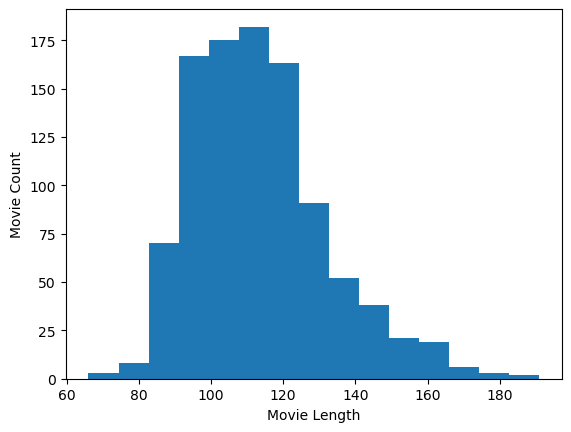

In [13]:
df.info()
df.describe()

runtime = df.iloc[:, 7]
plt2.hist(runtime, bins=15) 
plt2.xlabel('Movie Length')
plt2.ylabel('Movie Count')

plt2.show()

Cluster around 90 ~ 120 runtime (minutes)

'5) The mean i=IMDB rating for these movies is 6.72, std = 0.95, minimum is 1.9, 75%ile is 7.4


In [14]:
variance = df["Rating"].var()
stdev = df["Rating"].std()
print(variance)
print(stdev)

#low variance = ratings are clustered close together

0.8938355955955966
0.9454287892779638


In [16]:
top10 = df.nlargest(10, "Rating")[["Title", "Rating"]]
#[[]] gives me the columns I want.
#nlargest gives me top #.
print(top10)

                     Title  Rating
54         The Dark Knight     9.0
80               Inception     8.8
117                 Dangal     8.8
36            Interstellar     8.6
96           Kimi no na wa     8.6
249       The Intouchables     8.6
64            The Prestige     8.5
99            The Departed     8.5
124  The Dark Knight Rises     8.5
133               Whiplash     8.5


In [17]:
bottom5 = df.nsmallest(5, "Rating")[["Title", "Rating"]]
print(bottom5)

                       Title  Rating
829           Disaster Movie     1.9
42   Don't Fuck in the Woods     2.7
871     Dragonball Evolution     2.7
647                 Tall Men     3.2
890               The Intent     3.5


In [19]:
highrated = df[df["Rating"] > 8.5]
print(highrated[["Title", "Rating"]])
print(f"Total: {len(highrated)} movies")

                Title  Rating
36       Interstellar     8.6
54    The Dark Knight     9.0
80          Inception     8.8
96      Kimi no na wa     8.6
117            Dangal     8.8
249  The Intouchables     8.6
Total: 6 movies


In [40]:
correlation_runtime= df[["Runtime (Minutes)"]].corr()
correlation_votes= df[["Votes"]].corr()
correlation_rating= df[["Rating"]].corr()
print(correlation_runtime,correlation_votes,correlation_rating)

                   Runtime (Minutes)
Runtime (Minutes)                1.0        Votes
Votes    1.0         Rating
Rating     1.0


Both Votes and Runtime (Minutes) are positively correlated with Rating.

In [21]:
short_highrated = df[(df["Rating"] > 8.0) & (df["Runtime (Minutes)"] < 100)]
print(short_highrated[["Title", "Rating", "Runtime (Minutes)"]])

                              Title  Rating  Runtime (Minutes)
154  Twin Peaks: The Missing Pieces     8.1                 91
238        The Grand Budapest Hotel     8.1                 99
241                      Inside Out     8.2                 95
478                  Paint It Black     8.3                 96
499                              Up     8.3                 96
634                          WALL·E     8.4                 98
695             Hachi: A Dog's Tale     8.1                 93
772        How to Train Your Dragon     8.1                 98


they have high ratings despite being shorter in runtime.

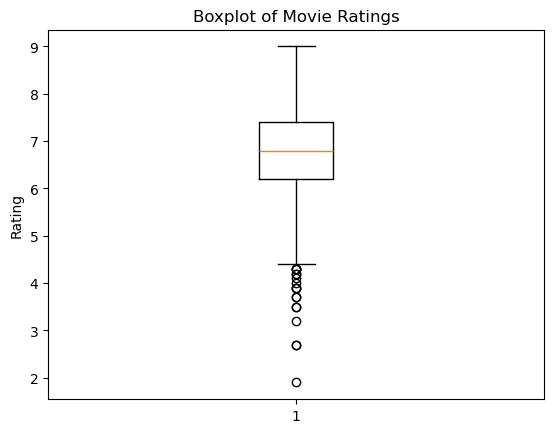

In [22]:
plt2.boxplot(df["Rating"])
plt2.title("Boxplot of Movie Ratings")
plt2.ylabel("Rating")
plt2.show()

In [25]:
genre_ratings = df.groupby("Genre")["Rating"].mean()
print(genre_ratings.sort_values(ascending=False))

Genre
Animation,Drama,Fantasy    8.60
Drama,Family,Music         8.50
Drama,Western              8.40
Animation,Drama,Romance    8.40
Adventure,Drama,Sci-Fi     8.30
                           ... 
Action,Fantasy,Thriller    5.20
Sci-Fi,Thriller            5.00
Sci-Fi                     4.95
Comedy,Western             4.80
Fantasy,Horror,Thriller    3.20
Name: Rating, Length: 207, dtype: float64


Animation,Drama,Fantasy is on top

In [42]:
#print(df.isnull().sum())
df_cleaned=df.dropna()
print(len(df.dropna()))

838


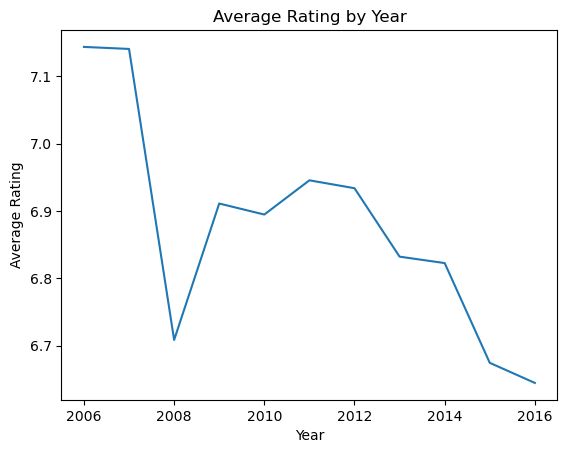

In [43]:
year_ratings = df_cleaned.groupby("Year")["Rating"].mean()

plt2.plot(year_ratings.index, year_ratings.values)
plt2.title("Average Rating by Year")
plt2.xlabel("Year")
plt2.ylabel("Average Rating")
plt2.show()

older movies tend to have higher ratings.

In [44]:
print(df_cleaned["Director"].value_counts())

Director
Ridley Scott          8
Paul W.S. Anderson    6
David Yates           6
Michael Bay           6
Antoine Fuqua         5
                     ..
Kyle Balda            1
Chris Renaud          1
Peter Billingsley     1
Lee Toland Krieger    1
Nima Nourizadeh       1
Name: count, Length: 524, dtype: int64


action, adventure sci-fi
comedy, drama, romance,
and drama
these are the top 3 most common genres.

In [45]:
mean_runtime = df_cleaned["Runtime (Minutes)"].mean()
std_runtime = df_cleaned["Runtime (Minutes)"].std()
print(mean_runtime)
print(std_runtime)
outliers = df_cleaned[df_cleaned["Runtime (Minutes)"] > mean_runtime + 2 * std_runtime]
print(outliers[["Title", "Runtime (Minutes)"]])

114.63842482100239
18.470922051554556
                                                 Title  Runtime (Minutes)
36                                        Interstellar                169
54                                     The Dark Knight                152
55                                             Silence                161
75            Pirates of the Caribbean: At World's End                169
77                                Inglourious Basterds                153
82                             The Wolf of Wall Street                180
87                                              Avatar                162
88                                   The Hateful Eight                187
90                                           Prisoners                153
124                              The Dark Knight Rises                164
126                    Transformers: Age of Extinction                165
129                                       The Revenant                156


In [46]:
mostvoted = df_cleaned.loc[df_cleaned.groupby("Genre")["Votes"].idxmax()]
#print(mostvoted[["Genre", "Title", "Votes"]])

print(mostvoted.sort_values("Votes", ascending=False)[["Genre", "Title", "Votes"]])

                       Genre                  Title    Votes
54        Action,Crime,Drama        The Dark Knight  1791916
80   Action,Adventure,Sci-Fi              Inception  1583625
124          Action,Thriller  The Dark Knight Rises  1222645
36    Adventure,Drama,Sci-Fi           Interstellar  1047747
76             Action,Sci-Fi           The Avengers  1045588
..                       ...                    ...      ...
793   Animation,Comedy,Drama    Ma vie de Courgette     4370
643        Drama,History,War                 Frantz     4304
110   Action,Horror,Thriller   The Belko Experiment     3712
949                Adventure                  Kicks     2417
616                   Sci-Fi   2307: Winter's Dream      277

[189 rows x 3 columns]
